In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [37]:
random_sample = np.random.randn(1000,)
#print(random_sample)

Ncases = random_sample.shape[0]

true_mean = 0.0

In [46]:
crps1 = np.abs(random_sample - true_mean)

print(crps1.shape)

crps2 = np.zeros((Ncases,Ncases))
crps2b = np.zeros((Ncases,Ncases))

for i in range(Ncases):
    for j in range(Ncases):
        crps2[i,j] = np.abs(random_sample[i] - random_sample[j])
        crps2b[i,j] = random_sample[i] - random_sample[j]

print(crps2.shape)

(1000,)
(1000, 1000)


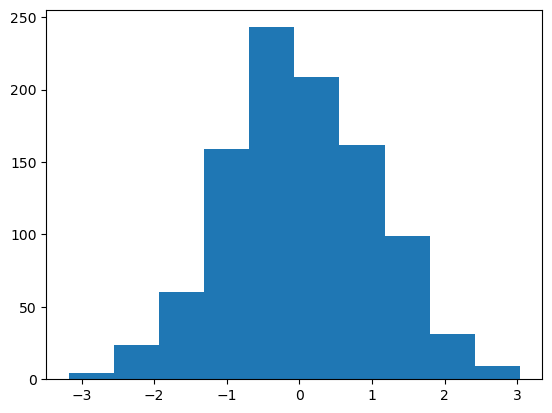

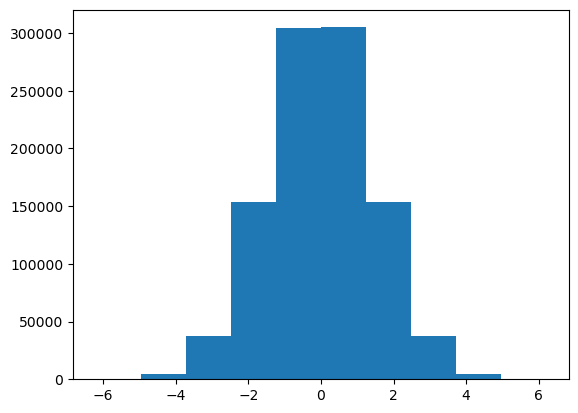

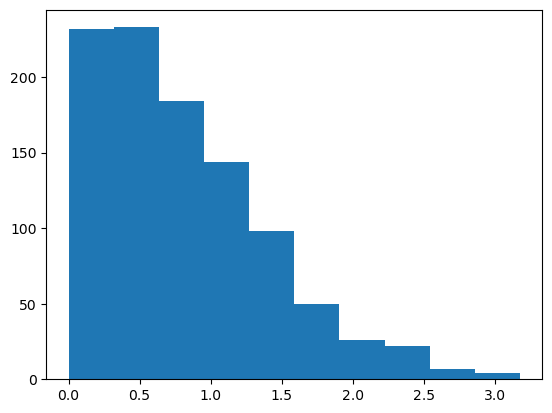

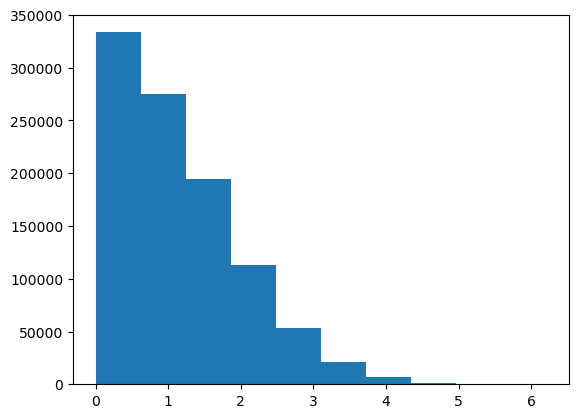

In [48]:
# Draw histogram of random sample
plt.hist(random_sample, bins=10)
plt.show()

# Draw histogram of crps2b
plt.hist(crps2b.flatten(), bins=10)
plt.show()

# Draw histogram of crps1
plt.hist(crps1, bins=10)
plt.show()

# Draw histogram of crps2
plt.hist(crps2.flatten(), bins=10)
plt.show()



In [44]:
crps1_total = 1 / Ncases * np.sum(crps1)
crps2_total = 1 / ( 2 * (Ncases**2) ) * np.sum(crps2)

print("CRPS_1: ", crps1_total)
print("CRPS_2: ", crps2_total)

print("Total CRPS: ", crps1_total - crps2_total)

CRPS_1:  0.819105563468994
CRPS_2:  0.5743734970272433
Total CRPS:  0.24473206644175072


In [52]:
def add_a_b(a, b):
    return a + b

print(add_a_b(1, 2))    

3


In [103]:
class Distribution:
    def __init__(self, values):
        self.values = values
        self.true_mean = np.mean(values)
        self.ncases = values.shape[0]

    def get_crps1(self):
        return np.abs(self.values - self.true_mean)

    # def get_crps2(self):
    #     #crps2 = np.zeros((self.ncases, self.ncases))
    #     for i in range(self.ncases):
    #         for j in range(self.ncases):
    #             crps2[i,j] = np.abs(self.values[i] - self.values[j])
    #         return crps2

    def get_crps2(self):
        v = self.values
        return np.abs(v[:, None] - v[None, :])

    def get_crps1_total(self):
        return 1 / self.ncases * np.sum(self.get_crps1())

    def get_crps2_total(self):
        return 1 / ( 2 * (self.ncases**2) ) * np.sum(self.get_crps2())

    def get_crps_total(self):
        return 1 / self.ncases * np.sum(self.get_crps1()) - 1 / ( 2 * (self.ncases**2) ) * np.sum(self.get_crps2())

    def get_fcrps_total(self):
        return 1 / self.ncases * np.sum(self.get_crps1()) - 1 / ( 2 * (self.ncases* (self.ncases-1)) ) * np.sum(self.get_crps2())

In [104]:
simple_linear_distribution = Distribution(np.linspace(0, 1, 100))

simple_linear_distribution.get_crps1_total(), simple_linear_distribution.get_crps2_total(), simple_linear_distribution.get_crps_total(), simple_linear_distribution.get_fcrps_total()

(np.float64(0.25252525252525254),
 np.float64(0.16833333333333336),
 np.float64(0.08419191919191918),
 np.float64(0.0824915824915825))

In [ ]:
class Distribution_and_sample:
    def __init__(self, distribution, sample):
        # Distribution attributes
        self.distribution = distribution
        self.ncases = distribution.shape[0]
        self.true_mean = np.mean(distribution)

        # Sample attributes
        self.sample = sample
        self.nsamples = sample.shape[0]

    def get_crps1(self):
        v1 = self.distribution
        v2 = self.sample
        return np.abs(v1 [:, None] - v2[None, :])

    def get_crps2(self):
        v = self.sample
        return np.abs(v[:, None] - v[None, :])

    def get_crps1_total(self):
        return 1 / (self.nsamples * self.ncases) * np.sum(self.get_crps1())

    def get_crps2_total(self):
        return 1 / ( 2 * (self.nsamples**2) ) * np.sum(self.get_crps2())

    def get_crps_total(self):
        return 1 / self.nsamples  * np.sum(self.get_crps1()) - 1 / ( 2 * (self.nsamples**2) ) * np.sum(self.get_crps2())

    def get_fcrps_total(self):
        return 1 / self.nsamples * np.sum(self.get_crps1()) - 1 / ( 2 * (self.nsamples* (self.nsamples-1)) ) * np.sum(self.get_crps2())

In [119]:
simple_linear_distribution = Distribution_and_sample(np.linspace(0, 1, 100), np.linspace(0, 10, 20))

print(simple_linear_distribution.get_crps1_total(), simple_linear_distribution.get_crps2_total(), simple_linear_distribution.get_crps_total(), simple_linear_distribution.get_fcrps_total())

simple_linear_distribution2 = Distribution_and_sample(np.linspace(0, 1, 100), np.linspace(0, 1, 100))

print(simple_linear_distribution2.get_crps1_total(), simple_linear_distribution2.get_crps2_total(), simple_linear_distribution2.get_crps_total(), simple_linear_distribution2.get_fcrps_total())

4.55 1.75 2.8 2.707894736842105
0.25252525252525254 0.16833333333333336 0.08419191919191918 0.0824915824915825


In [118]:
simple_linear_distribution.true_mean

np.float64(0.5)